# HDB Dataset — Exploratory Data Analysis

EDA on the cleaned HDB building dataset to uncover patterns in geography, building characteristics, dwelling composition, and development trends.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('../dataset/hdb_cleaned.csv')
print(f'Dataset: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

Dataset: 12441 rows × 36 columns


,blk_no,street,max_floor_lvl,year_completed,residential,commercial,market_hawker,miscellaneous,multistorey_carpark,precinct_pavilion,bldg_contract_town,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,lat,lng,building,addr,postal,SUBZONE_NO,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C
0,1,BEACH RD,16,1970,Y,Y,N,N,N,N,KWN,142,0,1,138,1,2,0,0,0,0,0,0,0,1.295097,103.854068,RAFFLES HOTEL,1 BEACH ROAD RAFFLES HOTEL SINGAPORE 189673,189673.0,2.0,CITY HALL,DTSZ02,DOWNTOWN CORE,DT,CENTRAL REGION,CR
1,1,BEDOK STH AVE 1,14,1975,Y,N,N,Y,N,N,BD,206,0,0,204,0,2,0,0,0,0,0,0,0,1.320852,103.933721,NaN,1 BEDOK SOUTH AVENUE 1 SINGAPORE 460001,460001.0,6.0,BEDOK SOUTH,BDSZ06,BEDOK,BD,EAST REGION,ER
2,1,CANTONMENT RD,2,2010,N,Y,N,N,N,N,CT,0,0,0,0,0,0,0,0,0,0,0,0,0,1.275488,103.841419,PINNACLE @ DUXTON,1 CANTONMENT ROAD PINNACLE @ DUXTON SINGAPORE ...,80001.0,3.0,CHINATOWN,OTSZ03,OUTRAM,OT,CENTRAL REGION,CR


---
## 1. Regional Distribution of HDB Buildings

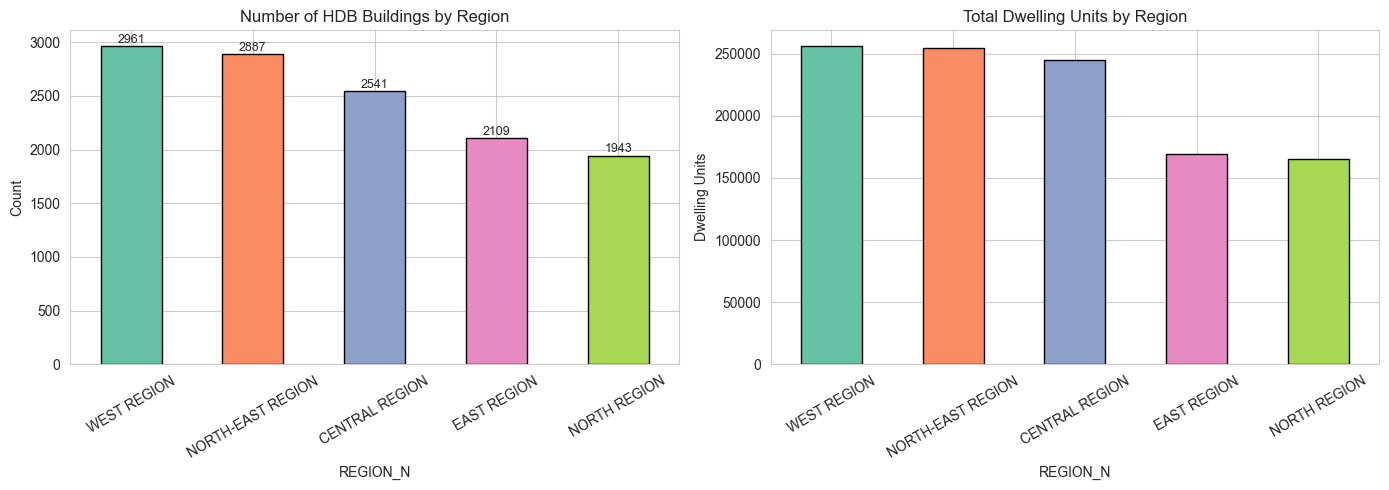

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Buildings per region
region_counts = df['REGION_N'].value_counts()
region_counts.plot.bar(ax=axes[0], color=sns.color_palette('Set2', len(region_counts)), edgecolor='black')
axes[0].set_title('Number of HDB Buildings by Region')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(region_counts):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=9)

# Total dwelling units per region
region_units = df.groupby('REGION_N')['total_dwelling_units'].sum().sort_values(ascending=False)
region_units.plot.bar(ax=axes[1], color=sns.color_palette('Set2', len(region_units)), edgecolor='black')
axes[1].set_title('Total Dwelling Units by Region')
axes[1].set_ylabel('Dwelling Units')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

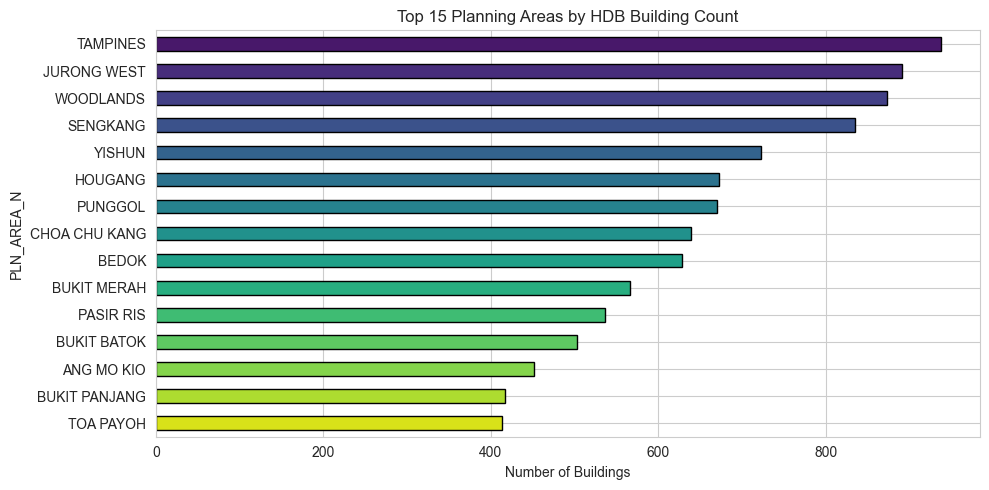

In [3]:
# Top 15 planning areas by building count
top_areas = df['PLN_AREA_N'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_areas.plot.barh(ax=ax, color=sns.color_palette('viridis', 15), edgecolor='black')
ax.set_xlabel('Number of Buildings')
ax.set_title('Top 15 Planning Areas by HDB Building Count')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 2. Geographic Scatter of HDB Buildings

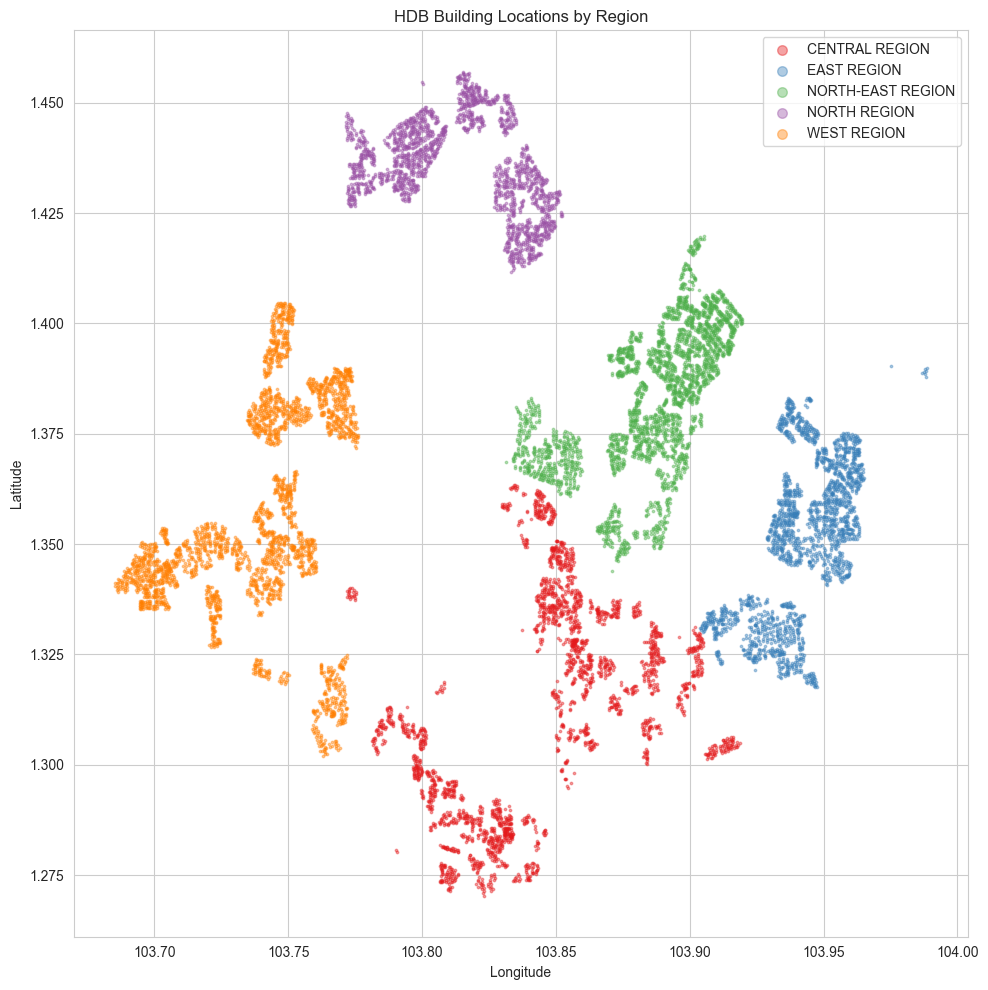

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))
regions = df['REGION_N'].unique()
palette = dict(zip(regions, sns.color_palette('Set1', len(regions))))

for region in regions:
    subset = df[df['REGION_N'] == region]
    ax.scatter(subset['lng'], subset['lat'], s=3, alpha=0.4,
               label=region, color=palette[region])

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('HDB Building Locations by Region')
ax.legend(markerscale=4, frameon=True)
plt.tight_layout()
plt.show()

---
## 3. Development Timeline

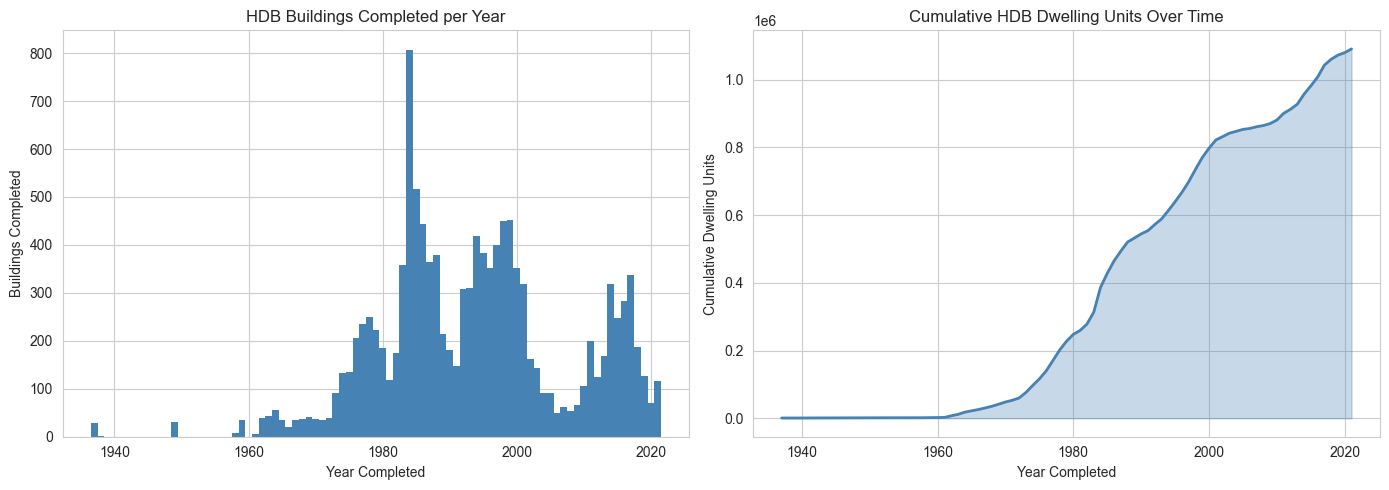

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Buildings completed per year
year_counts = df['year_completed'].value_counts().sort_index()
axes[0].bar(year_counts.index, year_counts.values, color='steelblue', edgecolor='none', width=1)
axes[0].set_xlabel('Year Completed')
axes[0].set_ylabel('Buildings Completed')
axes[0].set_title('HDB Buildings Completed per Year')

# Cumulative dwelling units over time
yearly_units = df.groupby('year_completed')['total_dwelling_units'].sum().sort_index().cumsum()
axes[1].fill_between(yearly_units.index, yearly_units.values, alpha=0.3, color='steelblue')
axes[1].plot(yearly_units.index, yearly_units.values, color='steelblue', linewidth=2)
axes[1].set_xlabel('Year Completed')
axes[1].set_ylabel('Cumulative Dwelling Units')
axes[1].set_title('Cumulative HDB Dwelling Units Over Time')

plt.tight_layout()
plt.show()

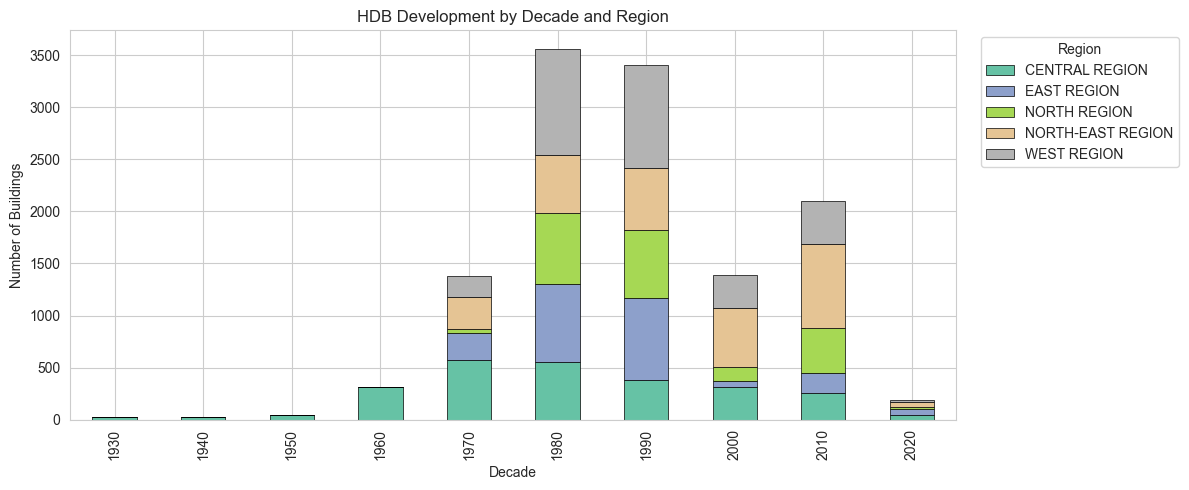

In [6]:
# Development by decade and region
df['decade'] = (df['year_completed'] // 10) * 10
decade_region = df.groupby(['decade', 'REGION_N']).size().unstack(fill_value=0)

decade_region.plot.bar(stacked=True, figsize=(12, 5),
                       colormap='Set2', edgecolor='black', linewidth=0.5)
plt.xlabel('Decade')
plt.ylabel('Number of Buildings')
plt.title('HDB Development by Decade and Region')
plt.legend(title='Region', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 4. Building Characteristics

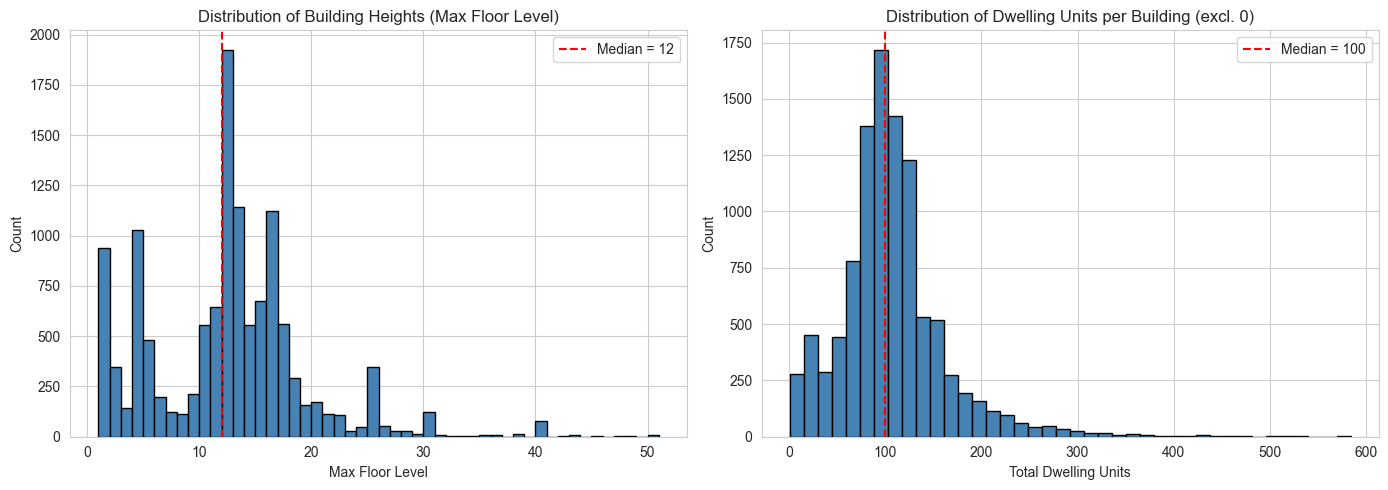

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Max floor level distribution
df['max_floor_lvl'].hist(bins=range(1, df['max_floor_lvl'].max() + 2),
                          ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_xlabel('Max Floor Level')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Building Heights (Max Floor Level)')
axes[0].axvline(df['max_floor_lvl'].median(), color='red', linestyle='--',
                label=f'Median = {df["max_floor_lvl"].median():.0f}')
axes[0].legend()

# Total dwelling units distribution
df['total_dwelling_units'][df['total_dwelling_units'] > 0].hist(
    bins=40, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Total Dwelling Units')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Dwelling Units per Building (excl. 0)')
axes[1].axvline(df.loc[df['total_dwelling_units'] > 0, 'total_dwelling_units'].median(),
                color='red', linestyle='--',
                label=f'Median = {df.loc[df["total_dwelling_units"] > 0, "total_dwelling_units"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

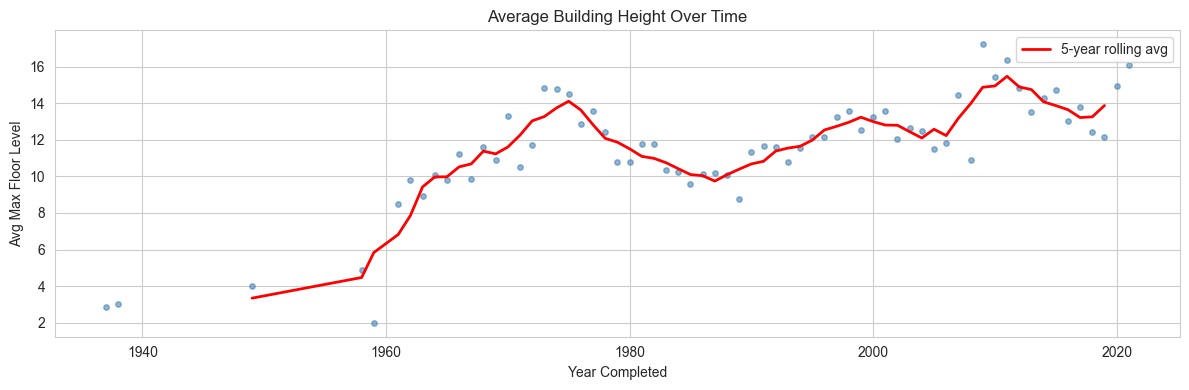

In [8]:
# Building height trend over time
height_by_year = df.groupby('year_completed')['max_floor_lvl'].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(height_by_year.index, height_by_year.values, s=15, alpha=0.6, color='steelblue')
# Rolling average
rolling = height_by_year.rolling(window=5, center=True).mean()
ax.plot(rolling.index, rolling.values, color='red', linewidth=2, label='5-year rolling avg')
ax.set_xlabel('Year Completed')
ax.set_ylabel('Avg Max Floor Level')
ax.set_title('Average Building Height Over Time')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Dwelling Unit Composition

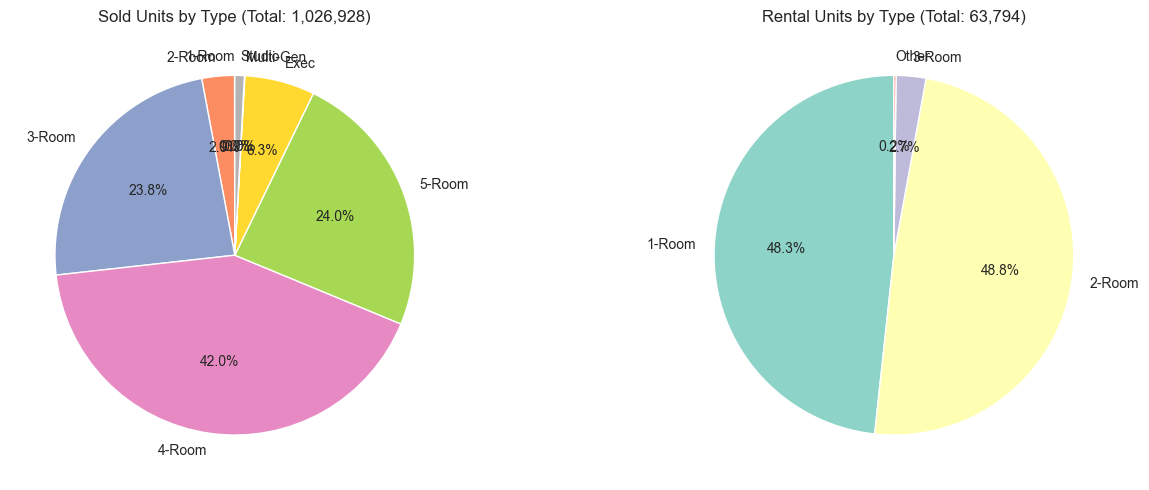

In [9]:
# Overall unit type breakdown
sold_cols = ['1room_sold', '2room_sold', '3room_sold', '4room_sold',
             '5room_sold', 'exec_sold', 'multigen_sold', 'studio_apartment_sold']
rental_cols = ['1room_rental', '2room_rental', '3room_rental', 'other_room_rental']

sold_totals = df[sold_cols].sum()
rental_totals = df[rental_cols].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sold units by type
labels_sold = ['1-Room', '2-Room', '3-Room', '4-Room', '5-Room', 'Exec', 'Multi-Gen', 'Studio']
sold_nonzero = sold_totals[sold_totals > 0]
labels_sold_nz = [labels_sold[i] for i in range(len(sold_totals)) if sold_totals.iloc[i] > 0]
axes[0].pie(sold_nonzero, labels=labels_sold_nz, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(sold_nonzero)), startangle=90)
axes[0].set_title(f'Sold Units by Type (Total: {sold_totals.sum():,})')

# Rental units by type
labels_rental = ['1-Room', '2-Room', '3-Room', 'Other']
rental_nonzero = rental_totals[rental_totals > 0]
labels_rental_nz = [labels_rental[i] for i in range(len(rental_totals)) if rental_totals.iloc[i] > 0]
axes[1].pie(rental_nonzero, labels=labels_rental_nz, autopct='%1.1f%%',
            colors=sns.color_palette('Set3', len(rental_nonzero)), startangle=90)
axes[1].set_title(f'Rental Units by Type (Total: {rental_totals.sum():,})')

plt.tight_layout()
plt.show()

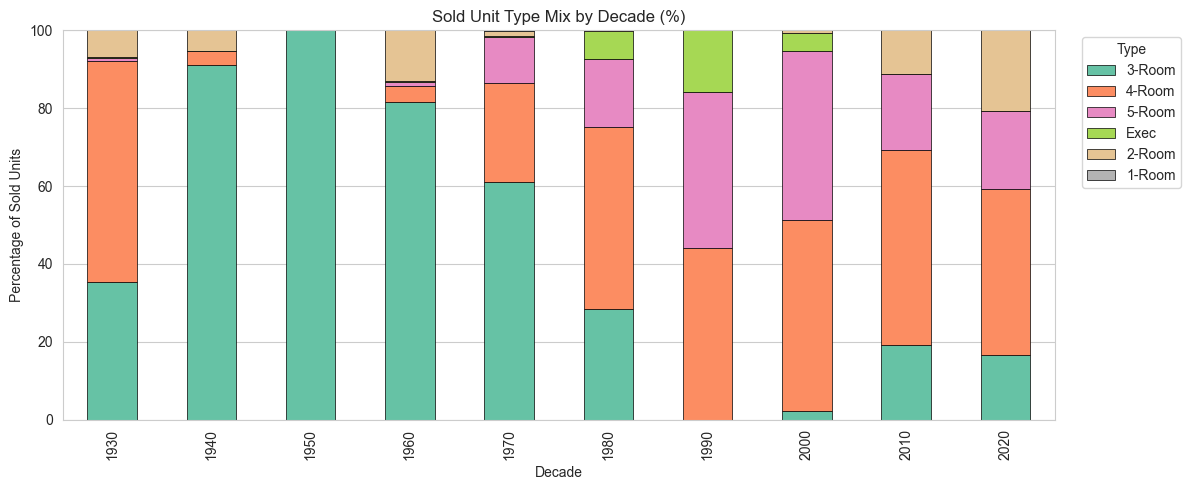

In [10]:
# Unit mix evolution by decade
unit_type_cols = ['3room_sold', '4room_sold', '5room_sold', 'exec_sold', '2room_sold', '1room_sold']
unit_labels = ['3-Room', '4-Room', '5-Room', 'Exec', '2-Room', '1-Room']

decade_mix = df.groupby('decade')[unit_type_cols].sum()
decade_mix.columns = unit_labels
decade_pct = decade_mix.div(decade_mix.sum(axis=1), axis=0) * 100

decade_pct.plot.bar(stacked=True, figsize=(12, 5),
                    colormap='Set2', edgecolor='black', linewidth=0.5)
plt.ylabel('Percentage of Sold Units')
plt.xlabel('Decade')
plt.title('Sold Unit Type Mix by Decade (%)')
plt.legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 6. Building Function Flags

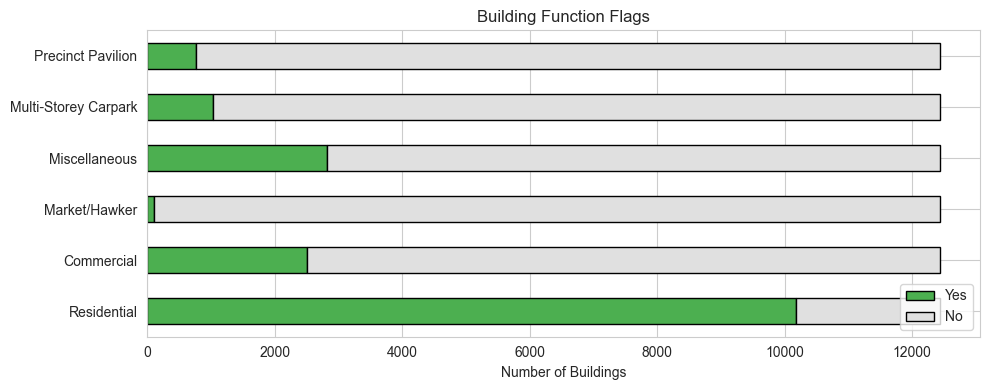

Percentage of buildings with each flag = Y:
Residential             81.8
Commercial              20.2
Market/Hawker            0.9
Miscellaneous           22.7
Multi-Storey Carpark     8.3
Precinct Pavilion        6.1


In [11]:
flag_cols = ['residential', 'commercial', 'market_hawker',
             'miscellaneous', 'multistorey_carpark', 'precinct_pavilion']

flag_counts = pd.DataFrame({
    'Yes': [(df[c] == 'Y').sum() for c in flag_cols],
    'No': [(df[c] == 'N').sum() for c in flag_cols]
}, index=['Residential', 'Commercial', 'Market/Hawker',
          'Miscellaneous', 'Multi-Storey Carpark', 'Precinct Pavilion'])

flag_counts.plot.barh(stacked=True, figsize=(10, 4),
                      color=['#4CAF50', '#E0E0E0'], edgecolor='black')
plt.xlabel('Number of Buildings')
plt.title('Building Function Flags')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Show percentages
flag_pct = (flag_counts['Yes'] / flag_counts.sum(axis=1) * 100).round(1)
print('Percentage of buildings with each flag = Y:')
print(flag_pct.to_string())

---
## 7. Correlation Analysis

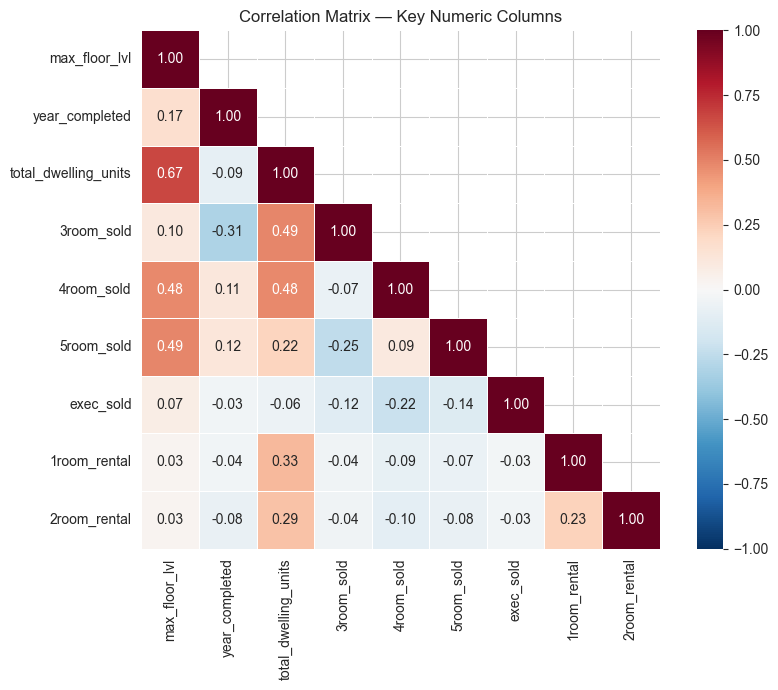

In [12]:
corr_cols = ['max_floor_lvl', 'year_completed', 'total_dwelling_units',
             '3room_sold', '4room_sold', '5room_sold', 'exec_sold',
             '1room_rental', '2room_rental']

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            linewidths=0.5)
ax.set_title('Correlation Matrix — Key Numeric Columns')
plt.tight_layout()
plt.show()

---
## 8. Regional Comparison — Key Metrics

In [13]:
region_stats = df.groupby('REGION_N').agg(
    buildings=('blk_no', 'count'),
    avg_floor_lvl=('max_floor_lvl', 'mean'),
    avg_dwelling_units=('total_dwelling_units', 'mean'),
    total_dwelling_units=('total_dwelling_units', 'sum'),
    avg_year=('year_completed', 'mean'),
    pct_residential=('residential', lambda x: (x == 'Y').mean() * 100)
).round(1).sort_values('buildings', ascending=False)

display(region_stats)

,buildings,avg_floor_lvl,avg_dwelling_units,total_dwelling_units,avg_year,pct_residential
REGION_N,,,,,,
WEST REGION,2961,12.3,86.5,255994,1994.1,82.7
NORTH-EAST REGION,2887,12.6,88.2,254541,1998.8,81.1
CENTRAL REGION,2541,13.1,96.4,244953,1986.0,77.9
EAST REGION,2109,10.7,80.5,169686,1991.6,85.1
NORTH REGION,1943,10.8,85.2,165560,1996.9,83.2


/var/folders/d7/dy_1gbj94754zmd2nnvsxq_c0000gn/T/ipykernel_43060/2337487999.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=residential, x='REGION_N', y='total_dwelling_units',


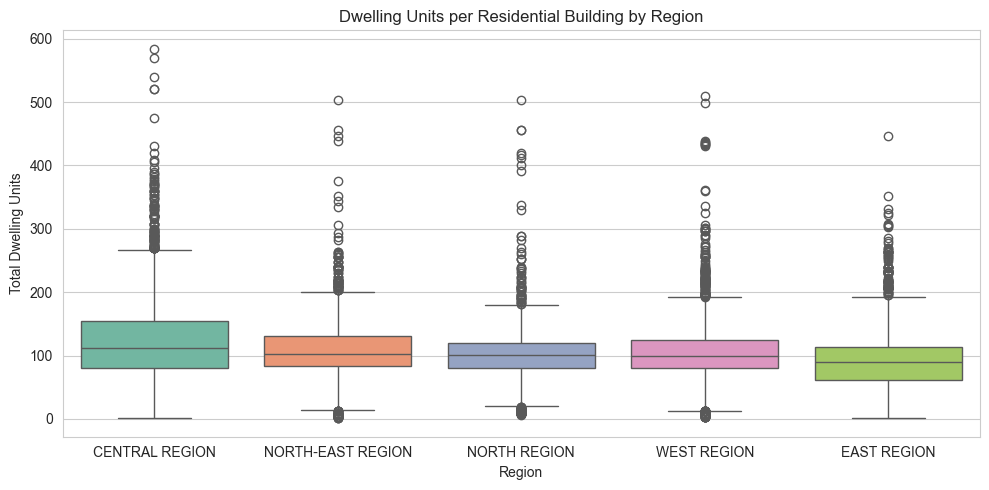

In [14]:
# Boxplot: dwelling units by region
residential = df[df['residential'] == 'Y']
order = residential.groupby('REGION_N')['total_dwelling_units'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=residential, x='REGION_N', y='total_dwelling_units',
            order=order, palette='Set2', ax=ax)
ax.set_xlabel('Region')
ax.set_ylabel('Total Dwelling Units')
ax.set_title('Dwelling Units per Residential Building by Region')
plt.tight_layout()
plt.show()

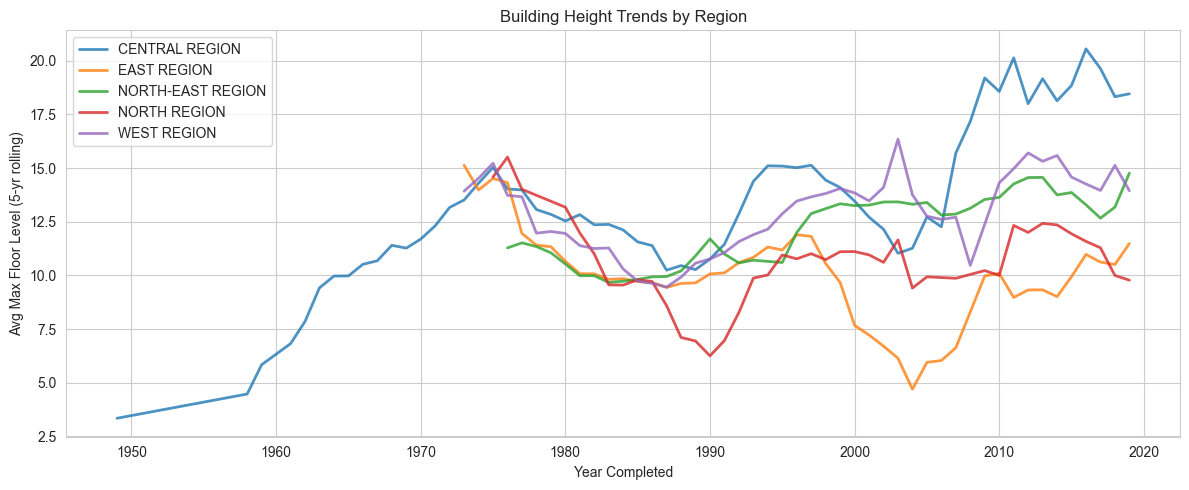

In [15]:
# Average building height by region over time
fig, ax = plt.subplots(figsize=(12, 5))

for region in df['REGION_N'].unique():
    subset = df[df['REGION_N'] == region]
    yearly = subset.groupby('year_completed')['max_floor_lvl'].mean()
    rolling = yearly.rolling(window=5, center=True).mean()
    ax.plot(rolling.index, rolling.values, linewidth=2, label=region, alpha=0.8)

ax.set_xlabel('Year Completed')
ax.set_ylabel('Avg Max Floor Level (5-yr rolling)')
ax.set_title('Building Height Trends by Region')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Key Takeaways

In [16]:
total_units = df['total_dwelling_units'].sum()
res_count = (df['residential'] == 'Y').sum()
peak_decade = df.groupby('decade').size().idxmax()
top_area = df['PLN_AREA_N'].value_counts().idxmax()
dominant_type = '4-Room'
avg_height = df['max_floor_lvl'].mean()

print('=== KEY TAKEAWAYS ===')
print(f'- {df.shape[0]:,} HDB buildings with {total_units:,} total dwelling units')
print(f'- {res_count:,} ({res_count/len(df)*100:.1f}%) are residential')
print(f'- Peak construction decade: {peak_decade}s')
print(f'- Most HDB-dense planning area: {top_area}')
print(f'- {dominant_type} flats dominate the sold unit mix')
print(f'- Average building height: {avg_height:.1f} floors')
print(f'- Building heights have generally increased over the decades')

# Clean up temp column
df.drop(columns='decade', inplace=True, errors='ignore')

=== KEY TAKEAWAYS ===
- 12,441 HDB buildings with 1,090,734 total dwelling units
- 10,181 (81.8%) are residential
- Peak construction decade: 1980s
- Most HDB-dense planning area: TAMPINES
- 4-Room flats dominate the sold unit mix
- Average building height: 12.0 floors
- Building heights have generally increased over the decades
